# # **Cálculo de Densidad desde un Archivo GSD (HOOMD-blue)**

In [13]:
import os
import numpy as np
import glob
import pandas as pd 
import matplotlib.pyplot as plt
from funciones import calcular_perfil_densidad_multi_especie

# Propiedades análisis
polimerizacion = [8, 16, 24]
temperaturas = [0.60]
epsilons = [0.25, 0.5, 1.0, 1.8, 2.0]

num_bines = 80
centro = num_bines // 2
margen = 5
margen_vapor = 6 

especies = ['S', 'P']

In [14]:
ruta_memoria = '/run/media/fabio-noriega/Almacen_Fabio/Simulaciones/Resultados/Polymers/P12_Polimero_Solvente'

In [15]:
# Inicializamos diccionarios para separar los resultados por especie
densidades_liquido = {esp: [] for esp in especies}
densidades_vapor = {esp: [] for esp in especies}
std_liquido = {esp: [] for esp in especies}
std_vapor = {esp: [] for esp in especies}

# Diccionario para almacenar los resultados estructurados
datos_grafico = {}

# --- PROCESAMIENTO Y CÁLCULO DE PERFILES DE DENSIDAD ---
# Iteramos directamente sobre las propiedades para no perder su rastro
for polim in polimerizacion:
    for temp in temperaturas:
        for eps in epsilons:
            # Construimos el nombre del archivo correspondiente a esta combinación
            archivo = f'Poly-Solv_T{temp:.2f}_epsSP{eps:.2f}_monom_{polim}.gsd'
            
            # (Asegúrate de que 'ruta_memoria' esté definida previamente en tu script)
            os.chdir(os.path.join(ruta_memoria))

            # Verificamos si el archivo realmente existe antes de procesarlo
            if not os.path.exists(archivo):
                print(f"⚠️ Archivo no encontrado, saltando: {archivo}")
                continue

            centros_x, resultados = calcular_perfil_densidad_multi_especie(
                gsd_file=archivo, tipos_interes=especies, start_frame=500, num_bines=num_bines
            )
            print(f'>> Procesado: {archivo}\n')

            # GUARDAMOS LOS METADATOS JUNTO CON LOS RESULTADOS
            datos_grafico[archivo] = {
                'centros_x': centros_x,
                'resultados': resultados,
                'propiedades': {
                    'T': temp,
                    'eps': eps,
                    'N': polim
                }
            }

            # Separar y promediar las fases para cada especie
            for esp in especies:
                rho_prom = resultados[esp]['promedio']
                rho_std = resultados[esp]['desviacion']

                # --- FASE LÍQUIDA ---
                bines_liquido = rho_prom.iloc[centro - margen : centro + margen]
                rho_l = bines_liquido.mean()
                
                bines_std_liquido = rho_std.iloc[centro - margen : centro + margen]
                std_l = bines_std_liquido.mean()

                # --- FASE VAPOR ---
                bines_vapor = np.concatenate([rho_prom.iloc[:margen_vapor], rho_prom.iloc[-margen_vapor:]])
                rho_v = bines_vapor.mean()
                
                bines_std_vapor = np.concatenate([rho_std.iloc[:margen_vapor], rho_std.iloc[-margen_vapor:]])
                std_v = bines_std_vapor.mean()

                densidades_liquido[esp].append(rho_l)
                std_liquido[esp].append(std_l)
                densidades_vapor[esp].append(rho_v)
                std_vapor[esp].append(std_v)

                print(f"  [{esp}] -> Región Líquido: {rho_l:.4f} ({std_l:.4f}) | Región Vapor: {rho_v:.4f} ({std_v:.4f})")

            print('-' * 40)

Cada frame tiene: 5000 pasos
La longitud de la caja es: 152.10379028320312
Procesando 101 frames para las especies: ['S', 'P']...
Frame procesado: 600/601
✅ Cálculo completado con éxito.
>> Procesado: Poly-Solv_T0.60_epsSP0.25_monom_8.gsd

  [S] -> Región Líquido: 0.8690 (0.0031) | Región Vapor: 0.0007 (0.0002)
  [P] -> Región Líquido: 0.0063 (0.0027) | Región Vapor: 0.0000 (0.0000)
----------------------------------------
Cada frame tiene: 5000 pasos
La longitud de la caja es: 152.10379028320312
Procesando 101 frames para las especies: ['S', 'P']...
Frame procesado: 600/601
✅ Cálculo completado con éxito.
>> Procesado: Poly-Solv_T0.60_epsSP0.50_monom_8.gsd

  [S] -> Región Líquido: 0.8690 (0.0029) | Región Vapor: 0.0007 (0.0002)
  [P] -> Región Líquido: 0.0075 (0.0022) | Región Vapor: 0.0000 (0.0000)
----------------------------------------
Cada frame tiene: 5000 pasos
La longitud de la caja es: 76.05189514160156
Procesando 101 frames para las especies: ['S', 'P']...
Frame procesado: 

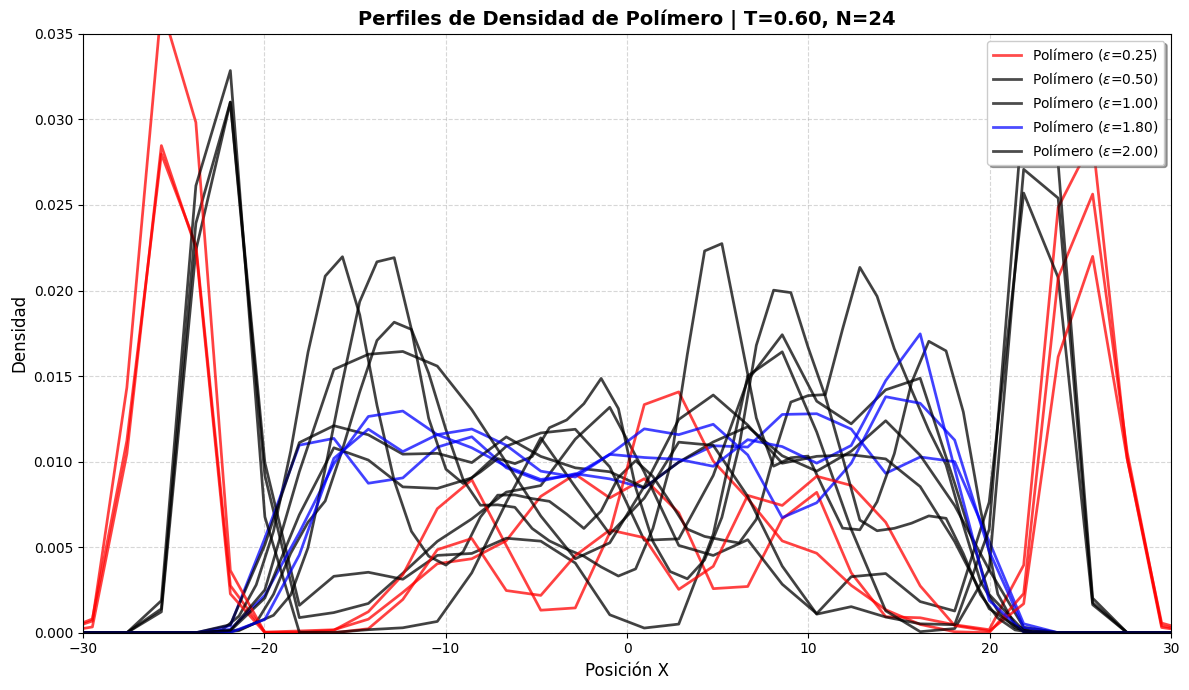

In [16]:
# --- SECCIÓN DE GRAFICADO ---
figura, ax = plt.subplots(figsize=(12, 7))

# Iteramos sobre los datos guardados
for archivo, contenido in datos_grafico.items():
    centros_x = contenido['centros_x']
    resultados = contenido['resultados']
    props = contenido['propiedades']  # Diccionario con T, eps, y N
    
    # =========================================================================
    # LOGICA DE ASIGNACIÓN DE COLORES POR PROPIEDADES
    # =========================================================================
    # Aquí puedes añadir las reglas lógicas que quieras según T, eps o N
    if props['eps'] == 0.25:
        color_archivo = 'red'
    elif props['eps'] == 1.8:
        color_archivo = 'blue'
    else:
        color_archivo = 'black' # Color por defecto si no entra en las anteriores
    # =========================================================================

    # Extraemos directamente los datos del Polímero ('P')
    promedio = resultados['P']['promedio']
    desviacion = 0

    y2 = promedio + desviacion

    etiqueta = f"Polímero ($\epsilon$={props['eps']:.2f})"


    # Graficado de la línea promedio
    ax.plot(centros_x, promedio, label=etiqueta, color=color_archivo, 
            linestyle='-', alpha=0.7, linewidth=2)
    
    # Sombreado de la desviación estándar
    ax.fill_between(centros_x, promedio, y2, color=color_archivo, alpha=0.15)

manejadores_existentes, etiquetas_existentes = ax.get_legend_handles_labels()
leyenda_filtrada = dict(zip(etiquetas_existentes, manejadores_existentes))

# Configuraciones finales del gráfico
ax.set_xlabel("Posición X", fontsize=12)
ax.set_ylabel("Densidad", fontsize=12)
ax.set_title(f"Perfiles de Densidad de Polímero | T={props['T']:.2f}, N={props['N']}", fontweight='bold', fontsize=14)

ax.legend(
    leyenda_filtrada.values(),  # Los manejadores de líneas únicos
    leyenda_filtrada.keys(),    # Las etiquetas de texto únicas
    loc='upper right',          # Posición interior derecha
    frameon=True,               # Fondo blanco activado
    shadow=True,                # Sombra para contraste
    fontsize='medium'
)

ax.grid(True, linestyle='--', alpha=0.5)
ax.set(ylim=(0.0, 0.035))
ax.set(xlim=(-30, 30))
plt.tight_layout()

plt.show()

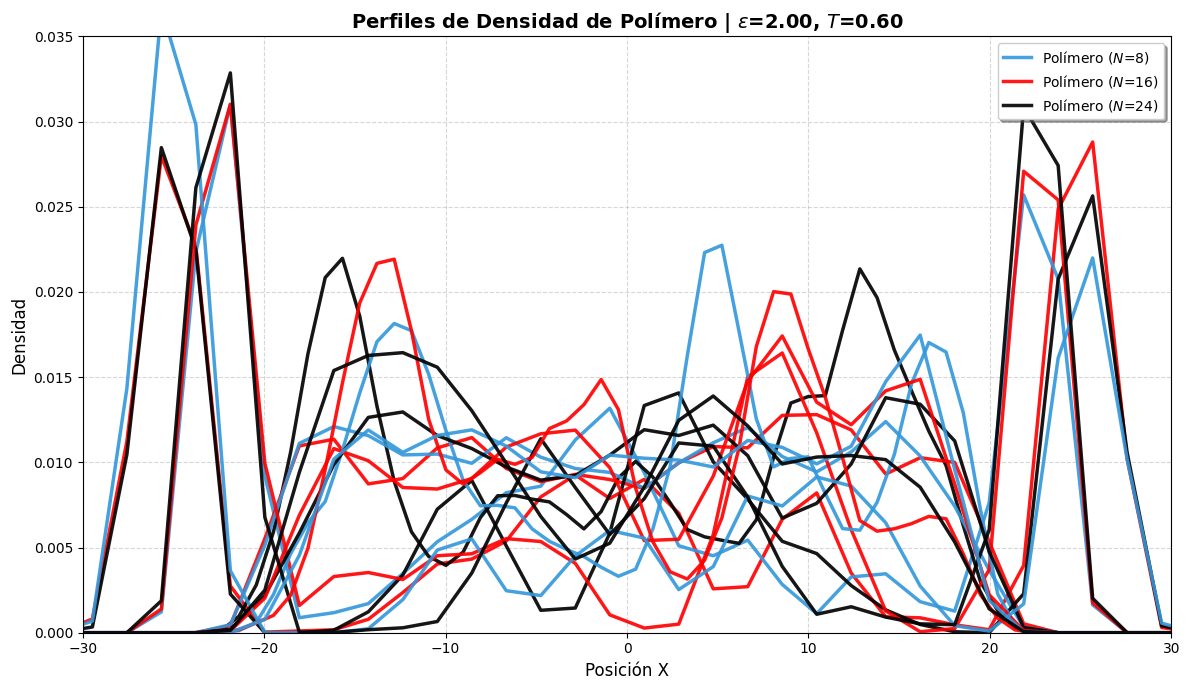

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# --- SECCIÓN DE GRAFICADO ---
figura, ax = plt.subplots(figsize=(12, 7))

# =========================================================================
# LISTA DE COLORES PERSONALIZADA (ALTO CONTRASTE)
# =========================================================================
colores_fijos = ['red', '#3498db', 'black']
# =========================================================================

# Iteramos sobre los datos guardados usando enumerate para obtener un índice
for i, (archivo, contenido) in enumerate(datos_grafico.items()):
    centros_x = contenido['centros_x']
    resultados = contenido['resultados']
    props = contenido['propiedades']  # Diccionario con T, eps, y N
    
    # Asignamos el color usando el operador módulo (%) por si hay más de 3 archivos
    color_archivo = colores_fijos[i % len(colores_fijos)]

    # Extraemos directamente los datos del Polímero ('P')
    promedio = resultados['P']['promedio']
    desviacion = 0  # Cambiar por la desviación real si la tienes

    y2 = promedio + desviacion

    # Etiqueta completa con epsilon, T y N
    etiqueta = f"Polímero ($N$={props['N']})"

    # Graficado de la línea promedio
    ax.plot(centros_x, promedio, label=etiqueta, color=color_archivo, 
            linestyle='-', alpha=0.9, linewidth=2.5)
    
    # Sombreado de la desviación estándar (mismo color, muy tenue)
    ax.fill_between(centros_x, promedio, y2, color=color_archivo, alpha=0.15)

manejadores_existentes, etiquetas_existentes = ax.get_legend_handles_labels()
leyenda_filtrada = dict(zip(etiquetas_existentes, manejadores_existentes))

# Configuraciones finales del gráfico
ax.set_xlabel("Posición X", fontsize=12)
ax.set_ylabel("Densidad", fontsize=12)
ax.set_title(f"Perfiles de Densidad de Polímero | $\epsilon$={props['eps']:.2f}, $T$={props['T']:.2f}", fontweight='bold', fontsize=14)

ax.legend(
    leyenda_filtrada.values(),  
    leyenda_filtrada.keys(),    
    loc='upper right',          
    frameon=True,               
    shadow=True,                
    fontsize='medium'
)

ax.grid(True, linestyle='--', alpha=0.5)
ax.set(ylim=(0.0, 0.035))
ax.set(xlim=(-30, 30))
plt.tight_layout()

plt.show()

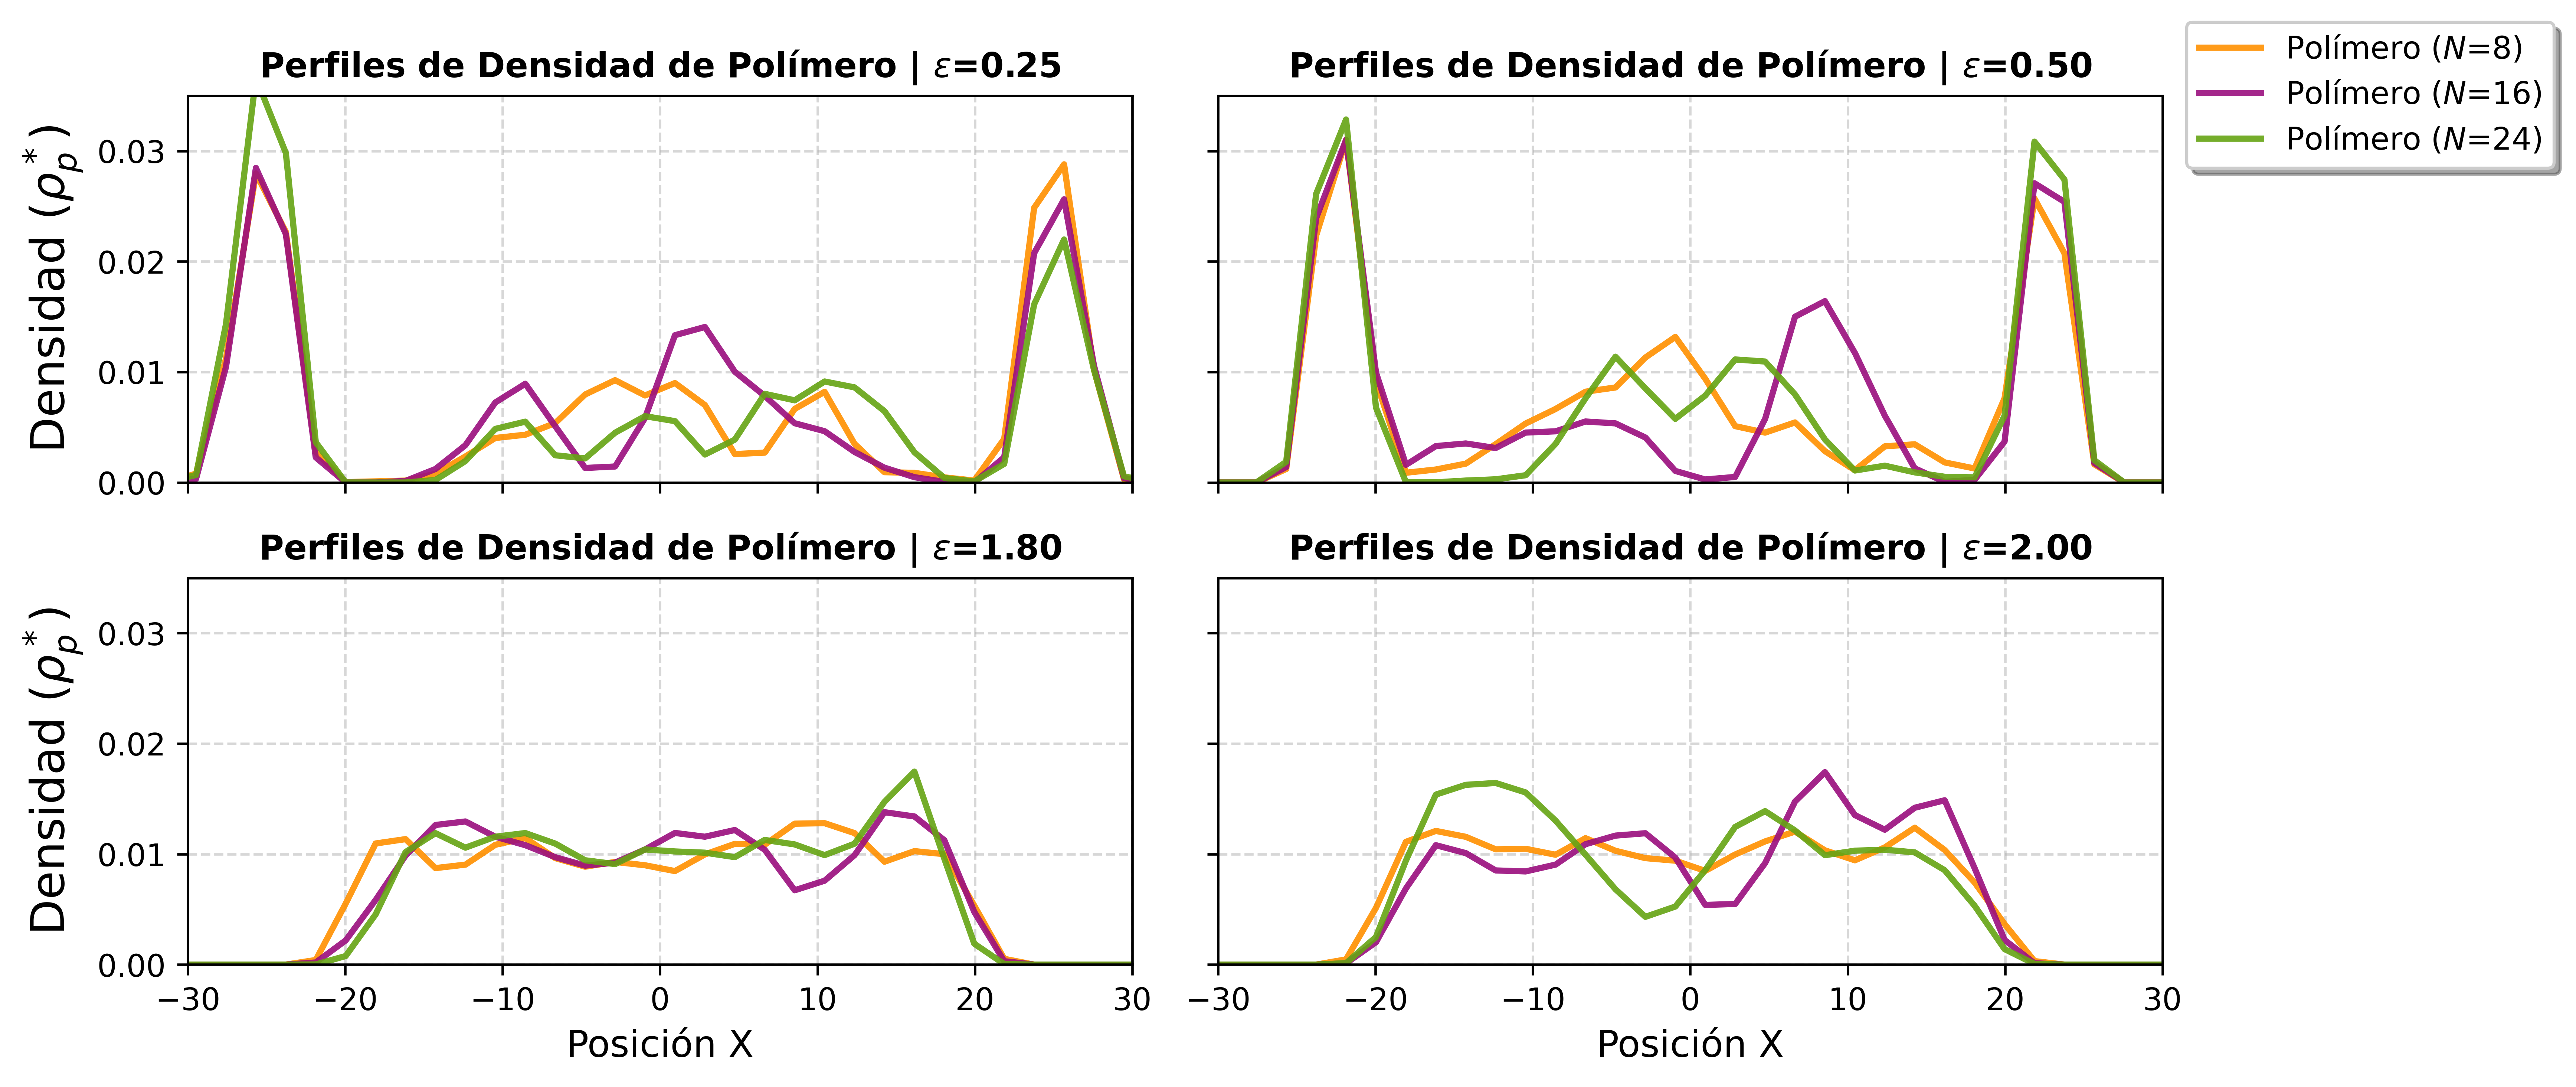

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# --- CONFIGURACIÓN DE LA FIGURA MULTIPANEL (2x2) ---
# Creamos la cuadrícula de 2 filas y 2 columnas
fig, ejes = plt.subplots(2, 2, figsize=(10, 5), sharex=True, sharey=True, dpi=600)

# Definimos las combinaciones exactas de las gráficas en el orden de tu imagen:
# Top-Left: eps=1.00, T=0.65 | Top-Right: eps=0.50, T=0.65
# Bot-Left: eps=1.00, T=0.60 | Bot-Right: eps=0.50, T=0.60
config_paneles = [
    {'eps': 0.25, 'T': 0.60, 'ax': ejes[0, 0]},
    {'eps': 0.5, 'T': 0.60, 'ax': ejes[0, 1]},
    {'eps': 1.8, 'T': 0.60, 'ax': ejes[1, 0]},
    {'eps': 2.0, 'T': 0.60, 'ax': ejes[1, 1]}
]

# Diccionario fijo de colores para asegurar que N=8, N=16 y N=24 tengan siempre el mismo color
colores_N = {8: '#ff9000', 16: '#9a0f7e', 24: '#66a414'}

# Listas auxiliares para capturar los objetos de la línea y usarlos en la leyenda única final
manejadores_leyenda = {}

# --- ITERACIÓN POR PANEL ---
for panel in config_paneles:
    ax_actual = panel['ax']
    eps_objetivo = panel['eps']
    T_objetivo = panel['T']
    
    # Buscamos en 'datos_grafico' las curvas que pertenezcan a este panel específico
    for archivo, contenido in datos_grafico.items():
        props = contenido['propiedades']
        
        # Si coincide con el epsilon y la temperatura de este cuadrante, lo graficamos
        if np.isclose(props['eps'], eps_objetivo) and np.isclose(props['T'], T_objetivo):
            centros_x = contenido['centros_x']
            resultados = contenido['resultados']
            N_valor = props['N']
            
            promedio = resultados['P']['promedio']
            desviacion = 0  # Cambiar por la desviación real si cuentas con ella
            y2 = promedio + desviacion
            
            color_linea = colores_N.get(N_valor, 'gray')
            etiqueta = f"Polímero ($N$={N_valor})"
            
            # Graficamos la línea
            linea, = ax_actual.plot(centros_x, promedio, label=etiqueta, color=color_linea, 
                                    linestyle='-', alpha=0.9, linewidth=2)
            
            # Sombreado de la desviación
            ax_actual.fill_between(centros_x, promedio, y2, color=color_linea, alpha=0.1)
            
            # Guardamos el objeto de la línea una sola vez por cada N para armar la leyenda global
            if N_valor not in manejadores_leyenda:
                manejadores_leyenda[N_valor] = linea

    # Configuración estética individual de cada panel
    ax_actual.set_title(f"Perfiles de Densidad de Polímero | $\epsilon$={eps_objetivo:.2f}", 
                        fontweight='bold', fontsize=11)
    ax_actual.grid(True, linestyle='--', alpha=0.5)
    ax_actual.set_ylim(0.0, 0.035)
    ax_actual.set_xlim(-30, 30)

# --- ETIQUETAS DE LOS EJES ---
# Colocamos etiquetas solo en los bordes exteriores para no saturar el gráfico
for row in range(2):
    ejes[row, 0].set_ylabel(r"Densidad ($\rho_p^*$)", fontsize=15)
for col in range(2):
    ejes[1, col].set_xlabel("Posición X", fontsize=12)

# --- CREACIÓN DE LA LEYENDA ÚNICA ---
# Ordenamos las leyendas por el tamaño de N (8, 16, 24)
N_ordenados = sorted(manejadores_leyenda.keys())
lineas_unicas = [manejadores_leyenda[n] for n in N_ordenados]
etiquetas_unicas = [lineas_unicas[i].get_label() for i in range(len(lineas_unicas))]

# Colocamos una única leyenda flotante en la esquina superior derecha de la figura entera
fig.legend(
    lineas_unicas, 
    etiquetas_unicas, 
    loc='upper left', 
    bbox_to_anchor=(0.98, 0.98), # Ajusta estos números si se enciman con los títulos
    frameon=True, 
    shadow=True, 
    fontsize='medium'
)

# Ajustamos los espacios entre los subplots para que no se pisen los títulos
plt.tight_layout()
# Dejamos un margen superior extra para que la leyenda global no tape los títulos de arriba
plt.subplots_adjust(top=0.90) 
plt.savefig('/run/media/fabio-noriega/Almacen_Fabio/Simulaciones/Resultados/Polymers/P12_Polimero_Solvente', dpi=600)

plt.show()

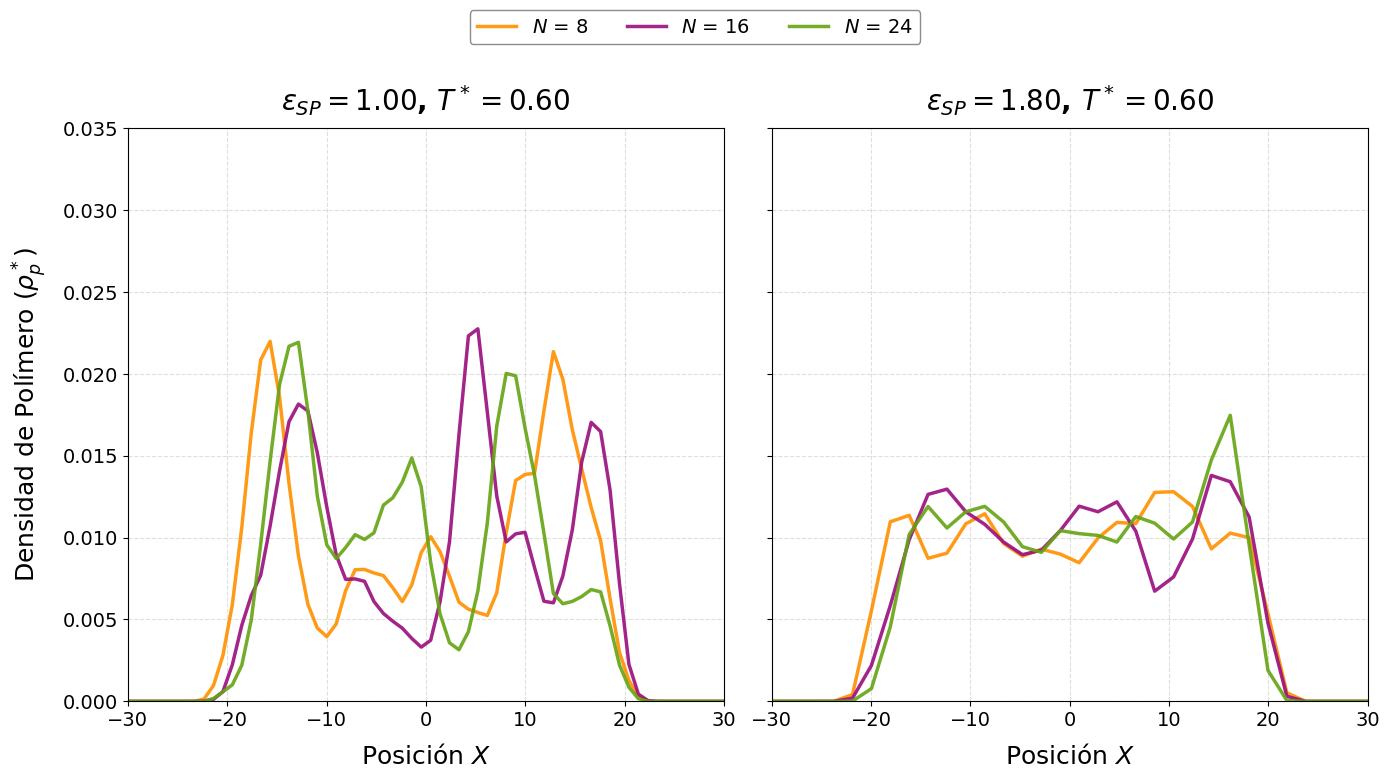

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# --- CONFIGURACIÓN DE LA FIGURA MULTIPANEL PARA PÓSTER (1 fila, 2 columnas) ---
# Cambiamos a 1 fila y 2 columnas, uno al lado del otro. Ajustamos el figsize.
fig, ejes = plt.subplots(1, 2, figsize=(14, 8), sharex=True, sharey=True)

# Filtramos únicamente las combinaciones con epsilon = 0.5
config_paneles = [
    {'eps': 1.0, 'T': 0.60, 'ax': ejes[0]}, # Panel Izquierdo
    {'eps': 1.8, 'T': 0.60, 'ax': ejes[1]}  # Panel Derecho
]

# Diccionario fijo de colores para asegurar uniformidad
colores_N = {8: '#ff9000', 16: '#9a0f7e', 24: '#66a414'}

# Listas auxiliares para la leyenda única final
manejadores_leyenda = {}

# --- ITERACIÓN POR PANEL ---
for panel in config_paneles:
    ax_actual = panel['ax']
    eps_objetivo = panel['eps']
    T_objetivo = panel['T']
    
    # Buscamos en 'datos_grafico' las curvas que pertenezcan a este panel específico
    for archivo, contenido in datos_grafico.items():
        props = contenido['propiedades']
        
        # Condición estricta: coincide con el epsilon (0.5) y la temperatura del panel
        if np.isclose(props['eps'], eps_objetivo) and np.isclose(props['T'], T_objetivo):
            centros_x = contenido['centros_x']
            resultados = contenido['resultados']
            N_valor = props['N']
            
            promedio = resultados['P']['promedio']
            desviacion = 0  # Cambiar por la desviación real si cuentas con ella
            y2 = promedio + desviacion
            
            color_linea = colores_N.get(N_valor, 'gray')
            etiqueta = f"$N$ = {N_valor}"
            
            # Graficamos las líneas con un grosor mayor (linewidth=2.5) para el póster
            linea, = ax_actual.plot(centros_x, promedio, label=etiqueta, color=color_linea, 
                                    linestyle='-', alpha=0.9, linewidth=2.5)
            
            # Sombreado de la desviación
            ax_actual.fill_between(centros_x, promedio, y2, color=color_linea, alpha=0.1)
            
            if N_valor not in manejadores_leyenda:
                manejadores_leyenda[N_valor] = linea

    # Configuración estética individual adaptada para póster
    ax_actual.set_title(f"$\epsilon_{{SP}} = {eps_objetivo:.2f}$, $T^* = {T_objetivo:.2f}$", 
                        fontweight='bold', fontsize=20, pad=12)
    ax_actual.grid(True, linestyle='--', alpha=0.4)
    ax_actual.set_ylim(0.0, 0.035)
    ax_actual.set_xlim(-30, 30)
    
    # Números de las escalas (Ticks) más grandes para legibilidad
    ax_actual.tick_params(axis='both', which='major', labelsize=14)

# --- ETIQUETAS DE LOS EJES GRANDES ---
ejes[0].set_ylabel(r"Densidad de Polímero ($\rho_p^*$)", fontsize=18, labelpad=10)
ejes[0].set_xlabel(r"Posición $X$", fontsize=18, labelpad=10)
ejes[1].set_xlabel(r"Posición $X$", fontsize=18, labelpad=10)

# --- CREACIÓN DE LA LEYENDA ÚNICA Y CENTRADA ---
N_ordenados = sorted(manejadores_leyenda.keys())
lineas_unicas = [manejadores_leyenda[n] for n in N_ordenados]
etiquetas_unicas = [lineas_unicas[i].get_label() for i in range(len(lineas_unicas))]

# Colocamos la leyenda centrada en la parte superior para aprovechar la horizontalidad
fig.legend(
    lineas_unicas, 
    etiquetas_unicas, 
    loc='upper center', 
    bbox_to_anchor=(0.5, 0.98), 
    frameon=True, 
    edgecolor='gray',
    framealpha=0.9,
    fontsize=14,
    ncol=3  # Desplegar N=8, N=16, N=24 horizontalmente en una sola fila
)

# Ajustamos espacios
plt.tight_layout()
# Dejamos espacio superior libre para la leyenda centrada
fig.subplots_adjust(top=0.82) 

# Guardar listo con la resolución ideal para el póster científico
# plt.savefig(ruta_memoria, dpi=400)
plt.show()